In [1]:
from sage.all import *
import itertools
from random import Random

# ============================================================
# Field construction
# ============================================================

def make_extension_field(q, n, gen_name='a'):
    """
    Construct F_{q^n} as an extension of F_q of degree n.
    Returns (F_q, F_q_n) as genuine FiniteField objects with
    F_q installed as a subfield of F_q_n, so that coercion and
    F_q_n.vector_space(F_q, ...) both work.
    """
    from sage.arith.misc import is_prime_power
    p, k = is_prime_power(q, get_data=True)
    if k == 0:
        raise ValueError(f"q = {q} is not a prime power")

    F_q_n = GF(p**(k * n), gen_name)
    if k == 1:
        F_q = F_q_n.prime_subfield()
    else:
        F_q = F_q_n.subfield(k, 'b')

    assert F_q_n.has_coerce_map_from(F_q)
    return F_q, F_q_n


# ============================================================
# q-cyclotomic cosets mod N = q^n - 1
# ============================================================

def nonzero_q_cyclotomic_coset_data(F_q_n, q):
    """
    Yield one record for each q-cyclotomic coset in F_q_n^*.

    If g is a multiplicative generator of F_q_n^* and N = |F_q_n^*|, then the
    nonzero element z = g^e has Frobenius orbit
        z, z^q, z^(q^2), ...
    corresponding exactly to the q-cyclotomic coset of e mod N.

    Yields dictionaries with keys:
        'rep_exp'   : representative exponent e
        'coset_exp' : full exponent coset
        'z0'        : g^e
        'orbit_z'   : [z0, z0^q, z0^(q^2), ...]
    """
    g = F_q_n.multiplicative_generator()
    N = ZZ(F_q_n.order() - 1)

    seen = bytearray(int(N))

    for e in range(int(N)):
        if seen[e]:
            continue

        x = e
        z0 = g**e
        w = z0
    
        coset = []
        orbit_z = []

        while not seen[x]:
            seen[x] = 1

            coset.append(ZZ(x))
            orbit_z.append(w)

            x = (x * q) % N
            w = w**q
            

        yield {
            'rep_exp': ZZ(e),
            'coset_exp': coset,
            'z0': z0,
            'orbit_z': orbit_z,
        }


# ============================================================
# Minimal polynomial over F_q from Frobenius orbit
# ============================================================

def minpoly_from_q_frobenius_orbit(orbit_z, F_q, var='t'):
    """
    Given the q-Frobenius orbit [z, z^q, z^(q^2), ...], return the minimal
    polynomial of z over F_q.

    Output:
        f_z in F_q[var]
    """
    F_q_polynomials = PolynomialRing(F_q, var)

    F_q_n = orbit_z[0].parent()
    F_q_n_polynomials = PolynomialRing(F_q_n, 'U')
    U = F_q_n_polynomials.gen()

    f_over_extension = prod(U - w for w in orbit_z)
    f_z = F_q_polynomials([F_q(c) for c in f_over_extension.list()])
    return f_z


# ============================================================
# Projective-point representatives in P(F_q_n)
# ============================================================

def projective_point_pair_iter(F_q, F_q_n, to_V):
    """
    Iterate over one representative for each projective F_q-point of F_q_n.

    Let N = q^n - 1 and Q = (q^n - 1)/(q - 1), and let g be a
    multiplicative generator of F_q_n^*. The elements

        g^0, g^1, ..., g^(Q-1)

    form one representative system for the projective F_q-lines in F_q_n.

    Yields:
        (k, g^k, to_V(g^k)) for k = 0, ..., Q-1.
    """
    g = F_q_n.multiplicative_generator()
    q = F_q.order()
    N = ZZ(F_q_n.order() - 1)
    Q = N // (q - 1)

    x = F_q_n(1)  # g^0
    for k in range(int(Q)):
        yield (ZZ(k), x, to_V(x))
        x *= g


def projective_point_pair_list(F_q, F_q_n, to_V):
    """
    Materialize the projective-point representatives once.
    """
    return list(projective_point_pair_iter(F_q, F_q_n, to_V))


# ============================================================
# Linear algebra over F_q
# ============================================================

def prepare_linear_algebra(F_q, F_q_n):
    """
    Prepare F_q_n as an F_q-vector space, together with conversion maps.

    Returns:
        V            : F_q-vector space
        from_V       : V -> F_q_n
        to_V         : F_q_n -> V
        basis_F_q_n  : basis of F_q_n over F_q, as field elements
        zero_v       : zero vector in V
    """
    V, from_V, to_V = F_q_n.free_module(base=F_q, map=True)
    basis_F_q_n = [from_V(v) for v in V.basis()]
    zero_v = V.zero()
    return V, from_V, to_V, basis_F_q_n, zero_v


def gamma_matrix_row_action(z, q, F_q, basis_F_q_n, to_V):
    """
    Matrix A over F_q for gamma_z(y) = z*y + y^q, in row-action convention:
        to_V(x) * A = to_V(gamma_z(x)).
    """
    rows = [to_V(z * b + b**q) for b in basis_F_q_n]
    return Matrix(F_q, rows)


def matrix_poly_eval_row_action(A, g_poly):
    """
    Evaluate polynomial g_poly at matrix A using Horner's rule.
    Row-action convention.
    """
    F_q = A.base_ring()
    n = A.nrows()
    I = identity_matrix(F_q, n)
    H = zero_matrix(F_q, n)

    for a in reversed(g_poly.list()):
        H = H * A
        if a != 0:
            H += F_q(a) * I

    return H


# ============================================================
# Factor data for m_{gamma_z}
# ============================================================

def m_gamma_factor_data(f_z, n, p, F_q_polynomials):
    """
    Compute factor data (polynomial itself, factorization & distinct factors and quotient_polynomials, i.e. m_gamma / factor_i) for
        m_gamma = f_z^(n/d) - 1
    using the p-part shortcut:
        if n/d = p^r * s with gcd(s, p) = 1, then
            f_z^(n/d) - 1 = (f_z^s - 1)^(p^r), where p is the characteristic of the field.
            It is then simpler to factorize f_z^s - 1 and adjust the multiplicities of the factors of m_gamma by multiplying with p^r.

    Theory:
    From Hsu and Nan (2011), it is known that the minimal polynomial of gamma_z is m_{gamma_z} = f_z^(n/deg(f_z)) - 1, 
    where f_z is the minimal polynomial of z over F_q.

    Returns:
        m_gamma        : full polynomial in F_q[t]
        reduced_fac    : factorization of f_z^s - 1
        full_fac       : factorization of m_gamma
        quotient_polys : [m_gamma / p_i] for distinct irreducible p_i
        distinct_facs  : [p_1, ..., p_l]
    """
    d = f_z.degree()
    e = ZZ(n // d)

    r = e.valuation(p)
    s = e // (p**r)

    reduced = f_z**s - F_q_polynomials(1)
    reduced_fac = list(reduced.factor())

    full_fac = [(pi, ai * (p**r)) for (pi, ai) in reduced_fac]

    m_gamma = F_q_polynomials(1)
    for pi, ei in full_fac:
        m_gamma *= pi**ei

    distinct_facs = [pi for (pi, _) in full_fac]
    quotient_polys = [m_gamma.quo_rem(pi)[0] for pi in distinct_facs]

    return m_gamma, reduced_fac, full_fac, quotient_polys, distinct_facs


# ============================================================
# Precomputation for fixed tau = gamma_z
# ============================================================

def precompute_tau_generator_test_data(
    z,
    orbit_z,
    F_q,
    n,
    lin_alg_data,
):
    """
    Precompute all fixed data needed to test whether x is a tau-generator for
    tau = gamma_z.

    Returns a dictionary containing:
        f_z, d, m_gamma, factorizations, quotient_polys, A, H_mats
    """
    q = F_q.order()
    p = F_q.characteristic()
    F_q_polynomials = PolynomialRing(F_q, 't')

    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data

    f_z = minpoly_from_q_frobenius_orbit(orbit_z, F_q, var='t')
    d = len(orbit_z)

    m_gamma, reduced_fac, full_fac, quotient_polys, distinct_facs = \
        m_gamma_factor_data(f_z, n, p, F_q_polynomials)

    A = gamma_matrix_row_action(z, q, F_q, basis_F_q_n, to_V)
    H_mats = [matrix_poly_eval_row_action(A, g_poly) for g_poly in quotient_polys]

    return {
        'z': z,
        'orbit_z': orbit_z,
        'f_z': f_z,
        'd': d,
        'm_gamma': m_gamma,
        'reduced_factorization': reduced_fac,
        'full_factorization': full_fac,
        'distinct_irreducible_factors': distinct_facs,
        'quotient_polys': quotient_polys,
        'A': A,
        'H_mats': H_mats,
    }


# ============================================================
# Stage 1: find ONE tau-generator u
# ============================================================

def one_tau_generator_via_evaluation_on_points(
    point_pairs,
    H_mats,
    zero_v,
):
    """
    Search one representative per nonzero F_q-point until a tau-generator is found.

    In row-action convention, x is a tau-generator iff
        x * H_i != 0
    for every H_i = (m_tau / p_i)(A).
    """
    checked_points = 0

    for point_exp, x_rep, vx_rep in point_pairs:
        checked_points += 1
        if all(vx_rep * H != zero_v for H in H_mats):
            return x_rep, vx_rep, checked_points, point_exp

    return None, None, checked_points, None


def one_tau_generator_via_kernels_on_points(
    point_pairs,
    H_mats,
):
    """
    Same search, but via the kernels v_i = ker(H_i).

    In row-action convention:
        v_i = { v : v * H_i = 0 } = right_kernel(H_i^T).
    """
    kernel_spaces = [H.transpose().right_kernel() for H in H_mats]
    checked_points = 0

    for point_exp, x_rep, vx_rep in point_pairs:
        checked_points += 1
        if all(vx_rep not in W for W in kernel_spaces):
            return x_rep, vx_rep, checked_points, point_exp, kernel_spaces

    return None, None, checked_points, None, kernel_spaces


# ============================================================
# Stage 2: cyclic-module coordinates from one generator u
# ============================================================

def prepare_cyclic_module_coordinates(u, A, lin_alg_data, verify=True):
    """
    Given one tau-generator u, build the cyclic basis
        u, u*A, u*A^2, ..., u*A^(n-1)
    in row-action convention.

    Returns:
        U_basis_matrix : matrix whose rows are u, uA, ..., uA^(n-1)
        u_vec          : coordinate row vector of u
    """
    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data
    n = A.nrows()
    F_q = A.base_ring()

    u_vec = to_V(u)
    rows = [u_vec]

    current = u_vec
    for _ in range(1, n):
        current = current * A
        rows.append(current)

    U_basis_matrix = Matrix(F_q, rows)

    if verify and U_basis_matrix.rank() != n:
        raise RuntimeError(
            "The chosen u was expected to be a tau-generator, but "
            "[u, tau(u), ..., tau^(n-1)(u)] does not have full rank."
        )

    return U_basis_matrix, u_vec


# ============================================================
# Exact enumeration of generator-points in module coordinates
# ============================================================

def monic_coprime_residue_data_iter(F_q, n, F_q_polynomials, distinct_facs):
    """
    Iterate over all monic polynomials a in F_q[t] of degree < n that are coprime
    to m_tau.

    Since scaling by F_q^* preserves tau-generatorhood, monic residues give one
    representative for each generator-projective point.

    Yields:
        (a, coeff_vec)
    where coeff_vec is the coefficient vector of length n:
        [a_0, a_1, ..., a_{n-1}]
    """
    one = F_q(1)
    zero = F_q(0)
    field_elements = tuple(F_q)

    # degree 0: only the monic constant 1
    coeffs = [one] + [zero] * (n - 1)
    yield F_q_polynomials([one]), vector(F_q, coeffs)

    # degrees 1,2,...,n-1
    for d in range(1, n):
        for lower_coeffs in itertools.product(field_elements, repeat=d):
            poly_coeffs = list(lower_coeffs) + [one]   # monic of degree d
            a = F_q_polynomials(poly_coeffs)

            # gcd(a, m_tau) = 1  <=>  no distinct irreducible factor divides a
            if any((a % pi) == 0 for pi in distinct_facs):
                continue

            coeffs = poly_coeffs + [zero] * (n - len(poly_coeffs))
            yield a, vector(F_q, coeffs)


# ============================================================
# Randomized sampling of generator-points in module coordinates
# ============================================================

def random_monic_coprime_residue_data_iter(
    F_q,
    n,
    F_q_polynomials,
    distinct_facs,
    trials,
    rng,
):
    """
    Yield up to 'trials' randomly sampled monic polynomials a of degree < n
    that are coprime to m_tau.

    This is a one-sided heuristic search generator: it may miss existing witnesses,
    but every yielded polynomial is valid for constructing a tau-generator.

    Yields:
        (a, coeff_vec)
    """
    one = F_q(1)
    zero = F_q(0)
    field_elements = tuple(F_q)

    for _ in range(trials):
        d = rng.randrange(n)   # random degree in {0, ..., n-1}

        if d == 0:
            a = F_q_polynomials([one])
            coeffs = [one] + [zero] * (n - 1)
            yield a, vector(F_q, coeffs)
            continue

        lower_coeffs = [field_elements[rng.randrange(len(field_elements))] for _ in range(d)]
        poly_coeffs = lower_coeffs + [one]
        a = F_q_polynomials(poly_coeffs)

        if any((a % pi) == 0 for pi in distinct_facs):
            continue

        coeffs = poly_coeffs + [zero] * (n - len(poly_coeffs))
        yield a, vector(F_q, coeffs)


# ============================================================
# Primitive testing
# ============================================================

def prepare_primitive_test_data(F_q, F_q_n):
    """
    Precompute data for exact primitive-element testing in F_q_n^*.

    Primitive iff x^(N/p) != 1 for every prime divisor p of N = q^n - 1.
    """
    N = ZZ(F_q_n.order() - 1)
    prime_divisors = [ZZ(p) for (p, _) in factor(N)]
    test_exponents = [N // p for p in prime_divisors]

    nonzero_scalars = [F_q_n(1)] + [
        F_q_n(c) for c in F_q if c != 0 and c != 1
    ]

    return {
        'N': N,
        'prime_divisors': prime_divisors,
        'test_exponents': test_exponents,
        'nonzero_scalars': nonzero_scalars,
    }


def is_primitive_element_from_test_data(x, primitive_test_data):
    """
    Exact primitive test using the prime divisors of |F_q_n^*|.
    """
    if x == 0:
        return False

    for e in primitive_test_data['test_exponents']:
        if x**e == 1:
            return False
    return True


# ============================================================
# Stage 3A: exhaustive exact search from one cyclic vector
# ============================================================

def primitive_tau_generator_from_one_cyclic_vector_exhaustive(
    u,
    A,
    m_gamma,
    distinct_facs,
    F_q,
    _F_q_n,
    lin_alg_data,
    primitive_test_data,
    verify_cyclic_basis=True,
):
    """
    Search exactly for a primitive tau-generator starting from one known tau-generator.
    
    Given one tau-generator u, consider all projective tau-generator representatives
    of the form
    
        a(tau)u
    
    where a is monic, deg(a) < n, and gcd(a, m_tau) = 1.
    
    For each such representative, test all nonzero scalar multiples
    
        lambda * a(tau)u,    lambda in F_q^*
    
    for multiplicative primitivity.
    
    The search stops immediately once a primitive element is found. Hence the
    procedure is exhaustive only in the negative case: if no primitive element is
    returned, then all admissible monic polynomials a and all scalar multiples have
    been tested.
    
    Returns:
        witness:
            A primitive tau-generator if one is found, otherwise None.
    
        diagnostics_dict:
            Diagnostic information about the search, including the number of
            generator-points checked, the number of primitive tests performed, and
            the polynomial/scalar data for a found witness when available.
    """
    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data
    n = A.nrows()
    F_q_polynomials = m_gamma.parent()

    U_basis_matrix, u_vec = prepare_cyclic_module_coordinates(
        u=u,
        A=A,
        lin_alg_data=lin_alg_data,
        verify=verify_cyclic_basis,
    )

    monic_generators_checked = 0
    primitive_tests_done = 0

    for a, coeff_vec in monic_coprime_residue_data_iter(
        F_q=F_q,
        n=n,
        F_q_polynomials=F_q_polynomials,
        distinct_facs=distinct_facs,
    ):
        monic_generators_checked += 1

        x_vec = coeff_vec * U_basis_matrix
        x = from_V(x_vec)

        for lam in primitive_test_data['nonzero_scalars']:
            y = lam * x
            primitive_tests_done += 1
            if is_primitive_element_from_test_data(y, primitive_test_data):
                return y, {
                    'cyclic_vector': u,
                    'cyclic_basis_rank_verified': verify_cyclic_basis,
                    'monic_generator_points_checked': monic_generators_checked,
                    'primitive_tests_done': primitive_tests_done,
                    'generator_polynomial': a,
                    'scalar': lam,
                    'search_mode_result': 'found',
                }

    return None, {
        'cyclic_vector': u,
        'cyclic_basis_rank_verified': verify_cyclic_basis,
        'monic_generator_points_checked': monic_generators_checked,
        'primitive_tests_done': primitive_tests_done,
        'generator_polynomial': None,
        'search_mode_result': 'exhausted_without_witness',
    }


# ============================================================
# Stage 3B: Randomized search from one cyclic vector
# ============================================================

def primitive_tau_generator_from_one_cyclic_vector_randomized(
    u,
    A,
    m_gamma,
    distinct_facs,
    F_q,
    _F_q_n,
    lin_alg_data,
    primitive_test_data,
    rng,
    randomized_trials=2000,
    verify_cyclic_basis=True,
):
    """
    Randomized search.

    Having found ONE tau-generator u, sample up to 'randomized_trials' many monic
    coprime residues a and test primitive elements among a(tau)u and its F_q^*-multiples.

    If no witness is found within the trial budget, returns None. Does NOT prove
    nonexistence.
    """
    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data
    n = A.nrows()
    F_q_polynomials = m_gamma.parent()

    U_basis_matrix, u_vec = prepare_cyclic_module_coordinates(
        u=u,
        A=A,
        lin_alg_data=lin_alg_data,
        verify=verify_cyclic_basis,
    )

    monic_generators_checked = 0
    primitive_tests_done = 0

    for a, coeff_vec in random_monic_coprime_residue_data_iter(
        F_q=F_q,
        n=n,
        F_q_polynomials=F_q_polynomials,
        distinct_facs=distinct_facs,
        trials=randomized_trials,
        rng=rng,
    ):
        monic_generators_checked += 1

        x_vec = coeff_vec * U_basis_matrix
        x = from_V(x_vec)

        for lam in primitive_test_data['nonzero_scalars']:
            y = lam * x
            primitive_tests_done += 1
            if is_primitive_element_from_test_data(y, primitive_test_data):
                return y, {
                    'cyclic_vector': u,
                    'cyclic_basis_rank_verified': verify_cyclic_basis,
                    'monic_generator_points_checked': monic_generators_checked,
                    'primitive_tests_done': primitive_tests_done,
                    'generator_polynomial': a,
                    'scalar': lam,
                    'search_mode_result': 'found',
                }

    return None, {
        'cyclic_vector': u,
        'cyclic_basis_rank_verified': verify_cyclic_basis,
        'monic_generator_points_checked': monic_generators_checked,
        'primitive_tests_done': primitive_tests_done,
        'generator_polynomial': None,
        'search_mode_result': 'trial_budget_exhausted',
    }


# ============================================================
# Primitive tau-generator search for one fixed z
# ============================================================

def find_primitive_tau_generator_for_z(
    z,
    orbit_z,
    F_q,
    F_q_n,
    n,
    lin_alg_data,
    point_pairs,
    primitive_test_data,
    method="evaluate",
    search_mode="exhaustive",
    randomized_trials=2000,
    rng=None,
    return_data=False,
    verify_cyclic_basis=True,
):
    """
    For fixed z in F_q_n with q-Frobenius orbit orbit_z, let tau = gamma_z.

    Strategy:
      1. find ONE tau-generator u
      2. switch to module coordinates via u
      3. generate all other tau-generators as a(tau)u with gcd(a, m_tau)=1
      4. test only multiplicative primitivity

    method:
        "evaluate"  -> find the first tau-generator u by vx * H_i != 0
        "kernel"    -> find the first tau-generator u via kernel membership

    search_mode:
        "exhaustive" -> exhaustive deterministic search
        "randomized" -> one-sided randomized search
    """
    if method not in {"evaluate", "kernel"}:
        raise ValueError("method must be 'evaluate' or 'kernel'")
    if search_mode not in {"exhaustive", "randomized"}:
        raise ValueError("search_mode must be 'exhaustive' or 'randomized'")

    if rng is None:
        rng = Random()

    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data

    precomp = precompute_tau_generator_test_data(
        z=z,
        orbit_z=orbit_z,
        F_q=F_q,
        n=n,
        lin_alg_data=lin_alg_data,
    )

    H_mats = precomp['H_mats']
    kernel_spaces = None

    # --------------------------------------------------------
    # Stage 1: find ONE tau-generator u
    # --------------------------------------------------------
    if method == "evaluate":
        u, u_vec, checked_points, u_point_exp = one_tau_generator_via_evaluation_on_points(
            point_pairs=point_pairs,
            H_mats=H_mats,
            zero_v=zero_v,
        )
    else:
        u, u_vec, checked_points, u_point_exp, kernel_spaces = \
            one_tau_generator_via_kernels_on_points(
                point_pairs=point_pairs,
                H_mats=H_mats,
            )

    if u is None:
        if not return_data:
            return None

        data = dict(precomp)
        data.update({
            'method': method,
            'search_mode': search_mode,
            'kernel_spaces': kernel_spaces,
            'one_generator_search_points_checked': checked_points,
            'one_generator_point_exp': None,
            'cyclic_vector': None,
            'monic_generator_points_checked': 0,
            'primitive_tests_done': 0,
            'generator_polynomial': None,
            'search_mode_result': 'no_tau_generator_found',
        })
        return None, data

    # --------------------------------------------------------
    # Stage 2 + 3: generate all further tau-generators from u
    # --------------------------------------------------------
    if search_mode == "exhaustive":
        witness, gen_data = primitive_tau_generator_from_one_cyclic_vector_exhaustive(
            u=u,
            A=precomp['A'],
            m_gamma=precomp['m_gamma'],
            distinct_facs=precomp['distinct_irreducible_factors'],
            F_q=F_q,
            _F_q_n=F_q_n,
            lin_alg_data=lin_alg_data,
            primitive_test_data=primitive_test_data,
            verify_cyclic_basis=verify_cyclic_basis,
        )
    else:
        witness, gen_data = primitive_tau_generator_from_one_cyclic_vector_randomized(
            u=u,
            A=precomp['A'],
            m_gamma=precomp['m_gamma'],
            distinct_facs=precomp['distinct_irreducible_factors'],
            F_q=F_q,
            _F_q_n=F_q_n,
            lin_alg_data=lin_alg_data,
            primitive_test_data=primitive_test_data,
            rng=rng,
            randomized_trials=randomized_trials,
            verify_cyclic_basis=verify_cyclic_basis,
        )

    if not return_data:
        return witness

    data = dict(precomp)
    data.update({
        'method': method,
        'search_mode': search_mode,
        'kernel_spaces': kernel_spaces,
        'one_generator_search_points_checked': checked_points,
        'one_generator_point_exp': u_point_exp,
        'cyclic_vector': gen_data['cyclic_vector'],
        'monic_generator_points_checked': gen_data['monic_generator_points_checked'],
        'primitive_tests_done': gen_data['primitive_tests_done'],
        'generator_polynomial': gen_data['generator_polynomial'],
        'search_mode_result': gen_data['search_mode_result'],
    })

    return witness, data


# ============================================================
# Full Carlitz-extensivity test
# ============================================================

def is_carlitz_extensive(
    q,
    n,
    method="evaluate",
    search_mode="exhaustive",
    randomized_trials=2000,
    random_seed=None,
    verbose=False,
    return_data=False,
    cache_projective_points=True,
    verify_cyclic_basis=True,
):
    """
    Test Carlitz-extensivity of F_{q^n} / F_q.

    Main ideas:
      - treat z = 0 separately
      - treat nonzero z via q-cyclotomic cosets mod q^n - 1
      - factor only one m_{gamma_z} per Frobenius orbit / minimal polynomial
      - search only ONE tau-generator u for each orbit representative z
      - then generate all further tau-generators via a(tau)u with gcd(a,m_tau)=1
      - test only multiplicative primitivity on those generated elements
      - transport witnesses along each orbit by x |-> x^q

    method:
      - "evaluate": usually fastest for finding the first tau-generator u
      - "kernel": computes the subspaces ker((m_tau/p_i)(tau))

    search_mode:
      - "exhaustive": exact. Returns True or False.
      - "randomized": one-sided. Returns True if witnesses are found for all orbits,
                      and None if the trial budget is exhausted somewhere.
                      It never returns False.

    If return_data=True, returns:
        (status, F_q, F_q_n, witnesses, diagnostics)

    where:
        status is
            True   -> extensive proved by actual witnesses
            False  -> non-extensive proved (only possible in exhaustive mode)
            None   -> unknown (only possible in randomized mode)

    witnesses[z] = primitive tau-generator for gamma_z
    diagnostics  = list of per-orbit diagnostic dicts
    """
    if method not in {"evaluate", "kernel"}:
        raise ValueError("method must be 'evaluate' or 'kernel'")
    if search_mode not in {"exhaustive", "randomized"}:
        raise ValueError("search_mode must be 'exhaustive' or 'randomized'")

    rng = Random(random_seed)

    F_q, F_q_n = make_extension_field(q, n)
    q0 = F_q.order()

    lin_alg_data = prepare_linear_algebra(F_q, F_q_n)
    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data

    primitive_test_data = prepare_primitive_test_data(F_q, F_q_n)

    point_pairs_cache = None
    if cache_projective_points:
        point_pairs_cache = projective_point_pair_list(F_q, F_q_n, to_V)

    witnesses = {}
    diagnostics = []

    def point_pairs_source():
        if point_pairs_cache is not None:
            return point_pairs_cache
        return projective_point_pair_iter(F_q, F_q_n, to_V)

    # --------------------------------------------------------
    # Case z = 0
    # --------------------------------------------------------
    z0 = F_q_n(0)
    orbit0 = [z0]

    primitive_x0, data0 = find_primitive_tau_generator_for_z(
        z=z0,
        orbit_z=orbit0,
        F_q=F_q,
        F_q_n=F_q_n,
        n=n,
        lin_alg_data=lin_alg_data,
        point_pairs=point_pairs_source(),
        primitive_test_data=primitive_test_data,
        method=method,
        search_mode=search_mode,
        randomized_trials=randomized_trials,
        rng=rng,
        return_data=True,
        verify_cyclic_basis=verify_cyclic_basis,
    )

    diagnostics.append(data0)

    if primitive_x0 is None:
        if search_mode == "exhaustive":
            if verbose:
                print("No primitive tau-generator exists for z = 0.")
            if return_data:
                return False, F_q, F_q_n, witnesses, diagnostics
            return False
        else:
            if verbose:
                print("Randomized search exhausted its budget for z = 0; status unknown.")
            if return_data:
                return None, F_q, F_q_n, witnesses, diagnostics
            return None

    witnesses[z0] = primitive_x0

    if verbose:
        print(
            f"z = 0, deg(f_z) = {data0['d']}, search_mode = {search_mode}, "
            f"points to find one generator = {data0['one_generator_search_points_checked']}, "
            f"generator-points checked = {data0['monic_generator_points_checked']}, "
            f"primitive tests = {data0['primitive_tests_done']}"
        )

    # --------------------------------------------------------
    # Nonzero z: one representative per q-cyclotomic coset
    # --------------------------------------------------------
    for coset_data in nonzero_q_cyclotomic_coset_data(F_q_n, q0):
        z_rep = coset_data['z0']
        orbit_z = coset_data['orbit_z']

        primitive_x_rep, data = find_primitive_tau_generator_for_z(
            z=z_rep,
            orbit_z=orbit_z,
            F_q=F_q,
            F_q_n=F_q_n,
            n=n,
            lin_alg_data=lin_alg_data,
            point_pairs=point_pairs_source(),
            primitive_test_data=primitive_test_data,
            method=method,
            search_mode=search_mode,
            randomized_trials=randomized_trials,
            rng=rng,
            return_data=True,
            verify_cyclic_basis=verify_cyclic_basis,
        )

        diagnostics.append(data)

        if primitive_x_rep is None:
            if search_mode == "exhaustive":
                if verbose:
                    print(
                        f"No primitive tau-generator exists for orbit representative z = {z_rep}."
                    )
                if return_data:
                    return False, F_q, F_q_n, witnesses, diagnostics
                return False
            else:
                if verbose:
                    print(
                        f"Randomized search exhausted its budget for orbit representative "
                        f"z = {z_rep}; status unknown."
                    )
                if return_data:
                    return None, F_q, F_q_n, witnesses, diagnostics
                return None

        # Frobenius transport:
        # if z_j = z_rep^(q^j), then x_j = x_rep^(q^j) works for z_j.
        xj = primitive_x_rep
        for zj in orbit_z:
            witnesses[zj] = xj
            xj = xj**q0

        if verbose:
            print(
                f"rep exp = {coset_data['rep_exp']}, "
                f"deg(f_z) = {data['d']}, search_mode = {search_mode}, "
                f"points to find one generator = {data['one_generator_search_points_checked']}, "
                f"generator-points checked = {data['monic_generator_points_checked']}, "
                f"primitive tests = {data['primitive_tests_done']}"
            )

    if return_data:
        return True, F_q, F_q_n, witnesses, diagnostics
    return True

Benchmark suite starting
cases = [(2, 2), (2, 4), (2, 6), (2, 8), (2, 10), (2, 12), (2, 14), (2, 16), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9)]
methods = ['evaluate_exhaustive', 'evaluate_randomized', 'kernel']
randomized_trials = auto
enforce_min_randomized_trials_qn = True
random_seed = 12345
cache_projective_points = True
verify_cyclic_basis = True

--- Case F_{2^2} / F_2 ---
field size q^n = 4
monic projective representatives = 3
[2^2] evaluate_exhaustive    status=False    time=    0.353410 s random_trials=0
[2^2] evaluate_randomized    status=Unknown  time=    0.002687 s random_trials=4
[2^2] kernel                 status=False    time=    0.017597 s random_trials=0

--- Case F_{2^4} / F_2 ---
field size q^n = 16
monic projective representatives = 15
[2^4] evaluate_exhaustive    status=True     time=    0.011082 s random_trials=0
[2^4] evaluate_randomized    status=Unknown  time=    0.004688 s random_trials=16
[2^4] kernel                 status=True     tim

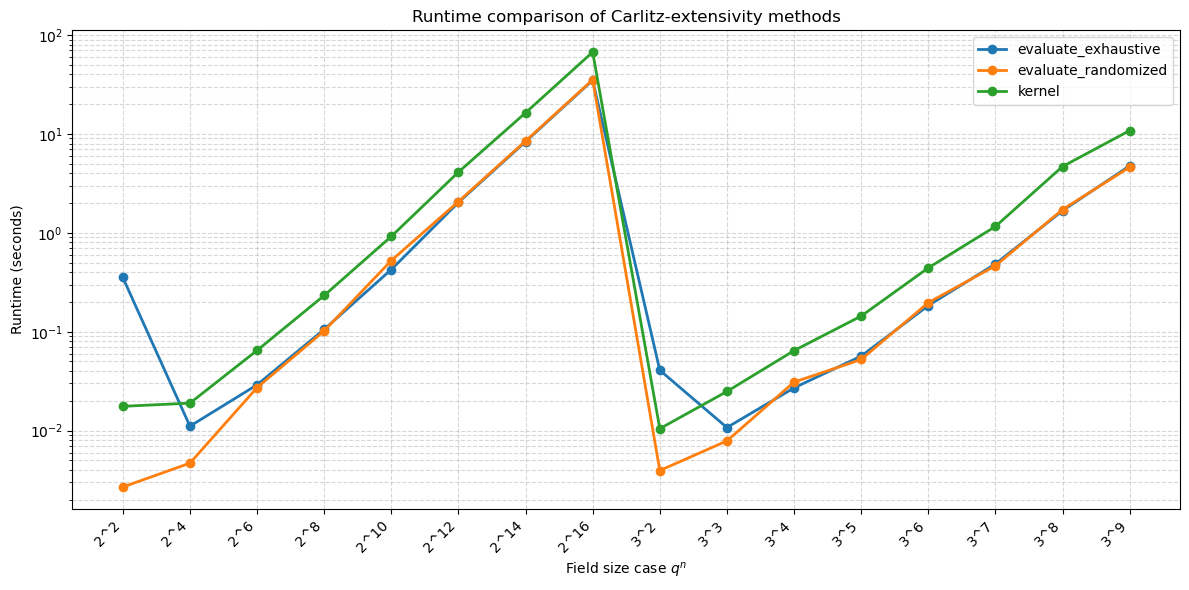

Saved plot to: benchmark_plot.png


In [ ]:
import time
import csv


# ============================================================
# Benchmark configuration
# ============================================================

BENCHMARK_METHODS = {
    "evaluate_exhaustive": {
        "method": "evaluate",
        "search_mode": "exhaustive",
        "uses_randomized_trials": False,
    },
    "evaluate_randomized": {
        "method": "evaluate",
        "search_mode": "randomized",
        "uses_randomized_trials": True,
    },
    "kernel": {
        "method": "kernel",
        "search_mode": "exhaustive",
        "uses_randomized_trials": False,
    },
}


def q_power_n(q, n):
    """
    Return q^n as an integer.
    """
    return int(q) ** int(n)


def number_of_monic_projective_representatives(q, n):
    """
    Number of monic polynomials a with deg(a) < n.

    This equals

        1 + q + ... + q^(n-1) = (q^n - 1) / (q - 1).

    It is also the number of projective points in F_{q^n} over F_q.
    """
    q = int(q)
    n = int(n)

    if q == 1:
        raise ValueError("q must be at least 2.")

    return (q**n - 1) // (q - 1)


def resolve_randomized_trials(
    q,
    n,
    randomized_trials="auto",
    *,
    enforce_min_qn=True,
):
    """
    Resolve the number of randomized sampling attempts.

    If randomized_trials == 'auto', use q^n.

    If randomized_trials is an integer and enforce_min_qn=True, use

        max(randomized_trials, q^n).

    Important:
        These are randomized sampling attempts passed to the core algorithm.
        With the current sampler, this does not guarantee that q^n distinct
        valid coprime monic polynomials are tested, because the sampler may
        draw duplicates and may skip non-coprime polynomials.
    """
    qn = q_power_n(q, n)

    if randomized_trials == "auto":
        return qn

    actual_trials = int(randomized_trials)

    if actual_trials < 0:
        raise ValueError("randomized_trials must be nonnegative.")

    if enforce_min_qn:
        actual_trials = max(actual_trials, qn)

    return actual_trials


def normalize_status(status):
    """
    Normalize the raw return value of is_carlitz_extensive.

    Expected meanings:
        True  -> proven / found
        False -> proven false
        None  -> unknown, usually randomized search failed to find a witness
    """
    if status is True:
        return "True", True
    if status is False:
        return "False", False
    return "Unknown", False


# ============================================================
# Single-method benchmark
# ============================================================

def benchmark_one_method(
    q,
    n,
    method_name,
    *,
    randomized_trials="auto",
    random_seed=12345,
    enforce_min_randomized_trials_qn=True,
    cache_projective_points=True,
    verify_cyclic_basis=True,
    verbose=False,
):
    """
    Time one run of is_carlitz_extensive(q, n, ...).

    Supported method_name values:
        - "evaluate_exhaustive"
        - "evaluate_randomized"
        - "kernel"

    Interpretation:
        evaluate_exhaustive:
            method="evaluate", search_mode="exhaustive"

        evaluate_randomized:
            method="evaluate", search_mode="randomized"

        kernel:
            method="kernel", search_mode="exhaustive"

    For evaluate_randomized, randomized_trials controls the number of
    randomized sampling attempts passed to the core algorithm.

    If randomized_trials == "auto", this benchmark uses q^n attempts.

    If enforce_min_randomized_trials_qn=True, then an explicitly given
    randomized_trials value is replaced by max(randomized_trials, q^n).

    Note:
        Randomized_trials is not necessarily the number of distinct 
        valid coprime monic polynomials tested. Samples may repeat,
        and non-coprime samples may be skipped internally.

    Returns:
        A dictionary containing timing data and benchmark metadata.
    """
    if method_name not in BENCHMARK_METHODS:
        valid = ", ".join(BENCHMARK_METHODS)
        raise ValueError(f"Unknown method_name={method_name!r}. Valid names: {valid}")

    method_config = BENCHMARK_METHODS[method_name]

    q = int(q)
    n = int(n)

    if q < 2:
        raise ValueError("q must be at least 2.")
    if n < 1:
        raise ValueError("n must be at least 1.")

    uses_randomized_trials = method_config["uses_randomized_trials"]

    if uses_randomized_trials:
        actual_randomized_trials = resolve_randomized_trials(
            q,
            n,
            randomized_trials=randomized_trials,
            enforce_min_qn=enforce_min_randomized_trials_qn,
        )
        actual_random_seed = random_seed
    else:
        actual_randomized_trials = 0
        actual_random_seed = None

    kwargs = {
        "q": q,
        "n": n,
        "method": method_config["method"],
        "search_mode": method_config["search_mode"],
        "randomized_trials": actual_randomized_trials,
        "random_seed": actual_random_seed,
        "verbose": verbose,
        "return_data": False,
        "cache_projective_points": cache_projective_points,
        "verify_cyclic_basis": verify_cyclic_basis,
    }

    t0 = time.perf_counter()
    status = is_carlitz_extensive(**kwargs)
    t1 = time.perf_counter()

    status_text, ok = normalize_status(status)

    qn = q_power_n(q, n)
    monic_projective_count = number_of_monic_projective_representatives(q, n)

    return {
        "q": q,
        "n": n,
        "label": f"{q}^{n}",
        "field_size": qn,
        "monic_projective_representatives": monic_projective_count,
        "method": method_name,
        "core_method": kwargs["method"],
        "search_mode": kwargs["search_mode"],
        "status": status_text,
        "ok": ok,
        "seconds": t1 - t0,
        "randomized_trials_requested": actual_randomized_trials,
        "random_seed": "" if actual_random_seed is None else actual_random_seed,
        "cache_projective_points": cache_projective_points,
        "verify_cyclic_basis": verify_cyclic_basis,
    }


# ============================================================
# One-case benchmark
# ============================================================

def benchmark_case(
    q,
    n,
    *,
    methods=None,
    randomized_trials="auto",
    random_seed=12345,
    enforce_min_randomized_trials_qn=True,
    cache_projective_points=True,
    verify_cyclic_basis=True,
    verbose=False,
):
    """
    Benchmark selected methods on one case (q, n).

    By default, runs:
        - evaluate_exhaustive
        - evaluate_randomized
        - kernel
    """
    if methods is None:
        methods = [
            "evaluate_exhaustive",
            "evaluate_randomized",
            "kernel",
        ]

    results = []

    for method_name in methods:
        row = benchmark_one_method(
            q=q,
            n=n,
            method_name=method_name,
            randomized_trials=randomized_trials,
            random_seed=random_seed,
            enforce_min_randomized_trials_qn=enforce_min_randomized_trials_qn,
            cache_projective_points=cache_projective_points,
            verify_cyclic_basis=verify_cyclic_basis,
            verbose=verbose,
        )

        results.append(row)

        print(
            f"[{row['label']}] "
            f"{row['method']:<22s} "
            f"status={row['status']:<8s} "
            f"time={row['seconds']:>12.6f} s "
            f"random_trials={row['randomized_trials_requested']}"
        )

    return results


# ============================================================
# Full benchmark suite
# ============================================================

def benchmark_suite(
    cases=None,
    *,
    methods=None,
    randomized_trials="auto",
    random_seed=12345,
    enforce_min_randomized_trials_qn=True,
    cache_projective_points=True,
    verify_cyclic_basis=True,
    verbose=False,
):
    """
    Benchmark a suite of cases.

    Default cases:
        q = 2: n = 2, 4, 6, 8, 10, 12, 14, 16
        q = 3: n = 2, 3, 4, 5, 6, 7, 8, 9

    Default methods:
        - evaluate_exhaustive
        - evaluate_randomized
        - kernel

    Randomized mode:
        If randomized_trials == "auto", the randomized method uses q^n
        sampling attempts for each case.

        If enforce_min_randomized_trials_qn=True, then even explicit integer
        values are raised to at least q^n.
    """
    if cases is None:
        cases = [
            (2, 2), (2, 4), (2, 6), (2, 8),
            (2, 10), (2, 12), (2, 14), (2, 16),
            (3, 2), (3, 3), (3, 4), (3, 5),
            (3, 6), (3, 7), (3, 8), (3, 9),
        ]

    if methods is None:
        methods = [
            "evaluate_exhaustive",
            "evaluate_randomized",
            "kernel",
        ]

    all_results = []

    print("=" * 88)
    print("Benchmark suite starting")
    print(f"cases = {cases}")
    print(f"methods = {methods}")
    print(f"randomized_trials = {randomized_trials}")
    print(f"enforce_min_randomized_trials_qn = {enforce_min_randomized_trials_qn}")
    print(f"random_seed = {random_seed}")
    print(f"cache_projective_points = {cache_projective_points}")
    print(f"verify_cyclic_basis = {verify_cyclic_basis}")
    print("=" * 88)

    for q, n in cases:
        qn = q_power_n(q, n)
        projective_count = number_of_monic_projective_representatives(q, n)

        print(f"\n--- Case F_{{{q}^{n}}} / F_{q} ---")
        print(f"field size q^n = {qn}")
        print(f"monic projective representatives = {projective_count}")

        case_results = benchmark_case(
            q=q,
            n=n,
            methods=methods,
            randomized_trials=randomized_trials,
            random_seed=random_seed,
            enforce_min_randomized_trials_qn=enforce_min_randomized_trials_qn,
            cache_projective_points=cache_projective_points,
            verify_cyclic_basis=verify_cyclic_basis,
            verbose=verbose,
        )

        all_results.extend(case_results)

    return all_results


# ============================================================
# Reporting
# ============================================================

def print_results_table(results):
    """
    Pretty-print benchmark results as a text table.
    """
    print("\n" + "=" * 140)
    print(
        f"{'case':<8} "
        f"{'method':<22} "
        f"{'status':<10} "
        f"{'time (s)':>12} "
        f"{'random trials':>15} "
        f"{'q^n':>12} "
        f"{'monic reps':>12}"
    )
    print("-" * 140)

    for row in results:
        print(
            f"{row['label']:<8} "
            f"{row['method']:<22} "
            f"{row['status']:<10} "
            f"{row['seconds']:>12.6f} "
            f"{row['randomized_trials_requested']:>15} "
            f"{row['field_size']:>12} "
            f"{row['monic_projective_representatives']:>12}"
        )

    print("=" * 140)


def save_results_csv(results, filename="benchmark_results.csv"):
    """
    Save benchmark results to a CSV file.
    """
    fieldnames = [
        "q",
        "n",
        "label",
        "field_size",
        "monic_projective_representatives",
        "method",
        "core_method",
        "search_mode",
        "status",
        "ok",
        "seconds",
        "randomized_trials_requested",
        "random_seed",
        "cache_projective_points",
        "verify_cyclic_basis",
    ]

    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)

    print(f"Saved CSV results to: {filename}")


def plot_results(
    results,
    filename="benchmark_plot.png",
    *,
    methods=None,
    logscale=True,
):
    """
    Create a timing plot with one x-position per test case and one line per method.
    """
    import matplotlib.pyplot as plt

    if methods is None:
        methods = [
            "evaluate_exhaustive",
            "evaluate_randomized",
            "kernel",
        ]

    labels = []
    seen_labels = set()

    for row in results:
        label = row["label"]
        if label not in seen_labels:
            labels.append(label)
            seen_labels.add(label)

    x = list(range(len(labels)))

    def time_for(label, method):
        for row in results:
            if row["label"] == label and row["method"] == method:
                seconds = row["seconds"]
                if seconds <= 0:
                    return float("nan")
                return seconds
        return float("nan")

    plt.figure(figsize=(12, 6))

    for method in methods:
        y = [time_for(label, method) for label in labels]
        plt.plot(x, y, marker="o", linewidth=2, label=method)

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.xlabel(r"Field size case $q^n$")
    plt.ylabel("Runtime (seconds)")
    plt.title("Runtime comparison of Carlitz-extensivity methods")

    if logscale:
        plt.yscale("log")

    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

    print(f"Saved plot to: {filename}")


RUN_STANDARD_BENCHMARKS = False

if RUN_STANDARD_BENCHMARKS:
    results = benchmark_suite(
        randomized_trials="auto",
        random_seed=12345,
        enforce_min_randomized_trials_qn=True,
        cache_projective_points=True,
        verify_cyclic_basis=True,
        verbose=False,
    )

    print_results_table(results)
    save_results_csv(results, "benchmark_results.csv")
    plot_results(results, "benchmark_plot.png", logscale=True)

In [ ]:
from sage.all import *
import time
import csv
import gc

# ============================================================
# Exhaustive-only benchmark cases
# ============================================================

EXHAUSTIVE_CASES = [
    (2, 18),
    (2, 20),
    (2, 24),
    (3, 12),
    (4, 10),
    (4, 12),
    (8, 8),
]


def run_exhaustive_case(
    q,
    n,
    *,
    method="evaluate",
    cache_projective_points=True,
    verify_cyclic_basis=True,
    verbose=False,
):
    """
    Run the exhaustive version:
        is_carlitz_extensive(q, n, method=method, search_mode="exhaustive")
    """

    label = f"{q}^{n}"
    print("=" * 72)
    print(f"Starting exhaustive run for {label}")
    print(f"method = {method}")
    print("=" * 72)

    t0 = time.perf_counter()

    status = is_carlitz_extensive(
        q,
        n,
        method=method,
        search_mode="exhaustive",
        randomized_trials=0,
        random_seed=None,
        cache_projective_points=cache_projective_points,
        verify_cyclic_basis=verify_cyclic_basis,
        verbose=verbose,
        return_data=False,
    )

    t1 = time.perf_counter()
    seconds = t1 - t0

    if status is True:
        status_text = "True"
    elif status is False:
        status_text = "False"
    else:
        status_text = "Unknown"

    row = {
        "q": q,
        "n": n,
        "label": label,
        "method": f"{method}_exhaustive",
        "status": status_text,
        "ok": status is True,
        "seconds": seconds,
    }

    print(f"Finished {label}: status={status_text}, time={seconds:.6f} s")
    print()

    gc.collect()
    return row


def run_exhaustive_suite(
    cases=EXHAUSTIVE_CASES,
    *,
    method="evaluate",
    cache_projective_points=True,
    verify_cyclic_basis=True,
    verbose=False,
    csv_filename="exhaustive_benchmark_results.csv",
):
    results = []

    for q, n in cases:
        row = run_exhaustive_case(
            q,
            n,
            method=method,
            cache_projective_points=cache_projective_points,
            verify_cyclic_basis=verify_cyclic_basis,
            verbose=verbose,
        )
        results.append(row)

        # Save after every case so partial results are preserved
        save_exhaustive_results_csv(results, csv_filename)

    return results


def save_exhaustive_results_csv(results, filename):
    fieldnames = [
        "q",
        "n",
        "label",
        "method",
        "status",
        "ok",
        "seconds",
    ]

    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)

    print(f"Saved current results to: {filename}")


def print_exhaustive_results_table(results):
    print("\n" + "=" * 80)
    print(f"{'case':<10} {'method':<24} {'status':<10} {'time (s)':>14}")
    print("-" * 80)

    for row in results:
        print(
            f"{row['label']:<10} "
            f"{row['method']:<24} "
            f"{row['status']:<10} "
            f"{row['seconds']:>14.6f}"
        )

    print("=" * 80)


# ============================================================
# Run exhaustive benchmark
# ============================================================

RUN_EXHAUSTIVE_BENCHMARKS = False

if RUN_EXHAUSTIVE_BENCHMARKS:
    exhaustive_results = run_exhaustive_suite(
        cases=EXHAUSTIVE_CASES,
        method="evaluate",
        cache_projective_points=True,
        verify_cyclic_basis=True,
        verbose=False,
        csv_filename="exhaustive_benchmark_results.csv",
    )

    print_exhaustive_results_table(exhaustive_results)

Starting exhaustive run for 2^18
method = evaluate
Finished 2^18: status=True, time=160.135329 s

Saved current results to: exhaustive_benchmark_results.csv
Starting exhaustive run for 2^20
method = evaluate
Finished 2^20: status=True, time=723.484832 s

Saved current results to: exhaustive_benchmark_results.csv
Starting exhaustive run for 2^24
method = evaluate
Finished 2^24: status=True, time=12272.865680 s

Saved current results to: exhaustive_benchmark_results.csv
Starting exhaustive run for 3^12
method = evaluate
Finished 3^12: status=True, time=301.813754 s

Saved current results to: exhaustive_benchmark_results.csv
Starting exhaustive run for 4^10
method = evaluate
Finished 4^10: status=True, time=1662.384249 s

Saved current results to: exhaustive_benchmark_results.csv
Starting exhaustive run for 4^12
method = evaluate
Finished 4^12: status=True, time=29095.351289 s

Saved current results to: exhaustive_benchmark_results.csv
Starting exhaustive run for 8^8
method = evaluate
Fin